In [7]:
import pydicom
import pandas as pd
import matplotlib
import torch
import torchvision
import numpy as np
from pathlib import Path

DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [8]:
labels= pd.read_csv('assignment1_labels.csv')
mapping = pd.read_csv('rsna_to_nih_mapping.csv')
print(labels.shape)
print(mapping.shape)

print(labels.head())

print(mapping.head())

(28989, 9)
(25684, 3)
                                           patientId      x      y  width  \
0  1.2.276.0.7230010.3.1.4.8323329.5872.151787431...    NaN    NaN    NaN   
1  1.2.276.0.7230010.3.1.4.8323329.15466.15178743...    NaN    NaN    NaN   
2  1.2.276.0.7230010.3.1.4.8323329.10973.15178743...  564.0  356.0  274.0   
3  1.2.276.0.7230010.3.1.4.8323329.10973.15178743...  195.0  320.0  281.0   
4  1.2.276.0.7230010.3.1.4.8323329.22658.15178744...    NaN    NaN    NaN   

   height  Target                                   StudyInstanceUID  \
0     NaN       0  1.2.276.0.7230010.3.1.2.8323329.5872.151787431...   
1     NaN       0  1.2.276.0.7230010.3.1.2.8323329.15466.15178743...   
2   496.0       1  1.2.276.0.7230010.3.1.2.8323329.10973.15178743...   
3   515.0       1  1.2.276.0.7230010.3.1.2.8323329.10973.15178743...   
4     NaN       0  1.2.276.0.7230010.3.1.2.8323329.22658.15178744...   

                                   SeriesInstanceUID  \
0  1.2.276.0.7230010.3.1.3

In [9]:
print(labels['StudyInstanceUID'].nunique())

25684


so from that we can understand that labels is 9 columnsut rows which is not similar to the amount of rows in the mapping this suppourts the information that a single patient image can have multiple detections and that labels have the exact amount of uniqueids for patients as the number of rows in the mapping file


In [10]:
df = labels.groupby('patientId')["Target"].max().reset_index()
print(df.shape)
print(df.head())

(25684, 2)
                                           patientId  Target
0  1.2.276.0.7230010.3.1.4.8323329.10001.15178743...       0
1  1.2.276.0.7230010.3.1.4.8323329.10002.15178743...       0
2  1.2.276.0.7230010.3.1.4.8323329.10004.15178743...       0
3  1.2.276.0.7230010.3.1.4.8323329.10005.15178743...       0
4  1.2.276.0.7230010.3.1.4.8323329.10006.15178743...       0


In [11]:
df= df.merge(mapping, how='left', on='patientId')
print(df.shape) 
print(df.head())

(25684, 4)
                                           patientId  Target  nih_patient_id  \
0  1.2.276.0.7230010.3.1.4.8323329.10001.15178743...       0           11683   
1  1.2.276.0.7230010.3.1.4.8323329.10002.15178743...       0            2245   
2  1.2.276.0.7230010.3.1.4.8323329.10004.15178743...       0           30355   
3  1.2.276.0.7230010.3.1.4.8323329.10005.15178743...       0           14758   
4  1.2.276.0.7230010.3.1.4.8323329.10006.15178743...       0            4082   

       nih_image_id  
0  00011683_018.png  
1  00002245_000.png  
2  00030355_000.png  
3  00014758_000.png  
4  00004082_008.png  


In [12]:
print(df['Target'].value_counts(normalize=True))

Target
0    0.779668
1    0.220332
Name: proportion, dtype: float64


In [13]:
from sklearn.model_selection import GroupShuffleSplit

gss= GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
first_idx,second_idx= next(gss.split(df, groups=df['nih_patient_id']))


In [14]:
from sklearn.model_selection import GroupShuffleSplit

gss= GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
first_idx,second_idx= next(gss.split(df, groups=df['nih_patient_id']))

train = df.iloc[first_idx]
temp = df.iloc[second_idx]
print(train.shape)
print(temp.shape)
print(df.shape)
gss= GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx,test_idx= next(gss.split(temp, groups=temp['nih_patient_id']))
val  = temp.iloc[val_idx]
test = temp.iloc[test_idx]
train_patients= set(train['nih_patient_id'])
val_patients= set(val['nih_patient_id'])
test_patients= set(test['nih_patient_id'])


(19124, 4)
(6560, 4)
(25684, 4)


In [15]:
assert len(train_patients & val_patients) == 0
assert len(train_patients & test_patients) == 0
assert len(val_patients & test_patients) == 0

In [16]:
print(train["Target"].value_counts(normalize=True))
print(val["Target"].value_counts(normalize=True))
print(test["Target"].value_counts(normalize=True))


Target
0    0.784825
1    0.215175
Name: proportion, dtype: float64
Target
0    0.751878
1    0.248122
Name: proportion, dtype: float64
Target
0    0.77889
1    0.22111
Name: proportion, dtype: float64


In [17]:
dicom_files = sorted(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))

for f in dicom_files[:3]:
    print(f.name, "|", f.stem)

print(df["patientId"].head(3).tolist())

DICOM files found: 25684
1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716.dcm | 1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716
1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592.dcm | 1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592
1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866.dcm | 1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866
['1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716', '1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592', '1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866']


In [18]:
# Build a lookup: patientId -> file path
id_to_path = {f.stem: f for f in dicom_files}

# Every file name should be unique
assert len(id_to_path) == len(dicom_files), "Two files share the same name"

# Compare the two sets of IDs
file_ids = set(id_to_path)
exam_ids = set(df["patientId"])
print("Examinations without a file:", len(exam_ids - file_ids))
print("Files without an examination:", len(file_ids - exam_ids))

# Add the path column
df["path"] = df["patientId"].map(id_to_path)
assert df["path"].notna().all(), "Some examinations have no image file"

Examinations without a file: 0
Files without an examination: 0


In [19]:
print(df["path"].head(3).tolist())

[PosixPath('data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.10001.1517874346.163715/1.2.276.0.7230010.3.1.3.8323329.10001.1517874346.163714/1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716.dcm'), PosixPath('data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.10002.1517874346.165591/1.2.276.0.7230010.3.1.3.8323329.10002.1517874346.165590/1.2.276.0.7230010.3.1.4.8323329.10002.1517874346.165592.dcm'), PosixPath('data/images/mdai_public_project_LxR6zdR2_images_2018-08-20-184248/1.2.276.0.7230010.3.1.2.8323329.10004.1517874346.174865/1.2.276.0.7230010.3.1.3.8323329.10004.1517874346.174864/1.2.276.0.7230010.3.1.4.8323329.10004.1517874346.174866.dcm')]


In [21]:
import pydicom

ds = pydicom.dcmread(df["path"].iloc[0])
print(ds)
print(ds.Rows, ds.Columns)
print(ds.PhotometricInterpretation)
print(ds.ViewPosition)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.10001.1517874346.163716
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

In [22]:
img = ds.pixel_array
print(img.shape, img.dtype, img.min(), img.max())

(1024, 1024) uint8 0 255


In [29]:
records = []
for pid, path in zip(df["patientId"], df["path"]):
    ds = pydicom.dcmread(path, stop_before_pixels=True)
    records.append({
        "patientId": pid,
        "rows": ds.Rows,
        "cols": ds.Columns,
        "photometric": ds.PhotometricInterpretation,
        "view": ds.ViewPosition,
        "sex": ds.PatientSex,
        "age": ds.PatientAge,
    })

meta = pd.DataFrame(records)
for col in ["rows", "cols", "photometric", "view", "sex"]:
    print(meta[col].value_counts())


rows
1024    25684
Name: count, dtype: int64
cols
1024    25684
Name: count, dtype: int64
photometric
MONOCHROME2    25684
Name: count, dtype: int64
view
PA    13979
AP    11705
Name: count, dtype: int64
sex
M    14593
F    11091
Name: count, dtype: int64


In [30]:
n = len(df)
df = df.merge(meta, on="patientId", how="left")
assert len(df) == n
assert df["view"].notna().all()

In [32]:
print(df.groupby("view")["Target"].mean())

view
AP    0.375481
PA    0.090421
Name: Target, dtype: float64


In [33]:
from sklearn.model_selection import GroupShuffleSplit

gss= GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
first_idx,second_idx= next(gss.split(df, groups=df['nih_patient_id']))

train = df.iloc[first_idx]
temp = df.iloc[second_idx]
print(train.shape)
print(temp.shape)
print(df.shape)
gss= GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx,test_idx= next(gss.split(temp, groups=temp['nih_patient_id']))
val  = temp.iloc[val_idx]
test = temp.iloc[test_idx]
train_patients= set(train['nih_patient_id'])
val_patients= set(val['nih_patient_id'])
test_patients= set(test['nih_patient_id'])


(19124, 11)
(6560, 11)
(25684, 11)


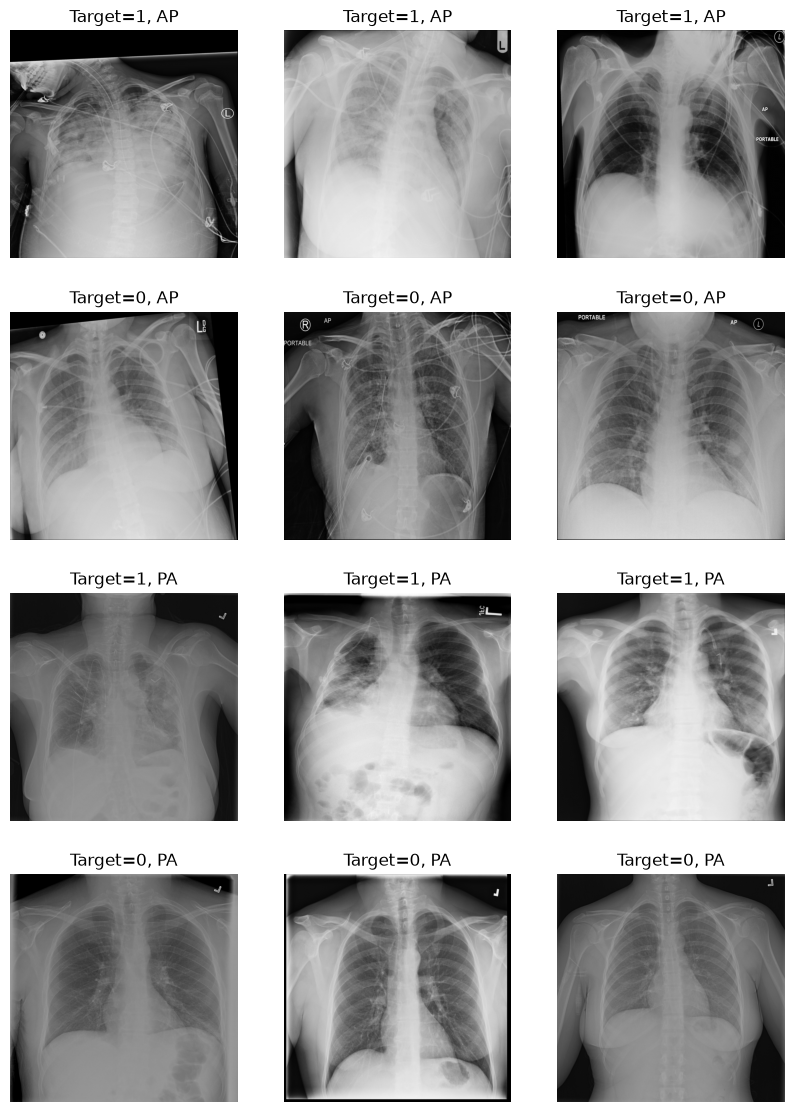

In [35]:
parts = []
for view in ["AP", "PA"]:
    for t in [1, 0]:
        group = train[(train["view"] == view) & (train["Target"] == t)]
        parts.append(group.sample(3, random_state=0))
examples = pd.concat(parts)

fig, axes = plt.subplots(4, 3, figsize=(10, 14))
for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    img = pydicom.dcmread(row["path"]).pixel_array
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Target={row['Target']}, {row['view']}")
    ax.axis("off")
plt.show()

1.2.276.0.7230010.3.1.4.8323329.28028.1517874482.812128


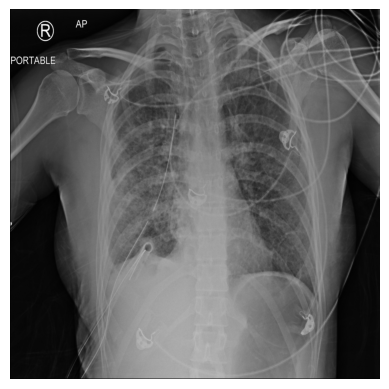

In [36]:
row = examples.iloc[4]
print(row["patientId"])
plt.imshow(pydicom.dcmread(row["path"]).pixel_array, cmap="gray")
plt.axis("off")
plt.show()

In [37]:
print(row)

patientId         1.2.276.0.7230010.3.1.4.8323329.28028.15178744...
Target                                                            0
nih_patient_id                                                27093
nih_image_id                                       00027093_002.png
path              data/images/mdai_public_project_LxR6zdR2_image...
rows                                                           1024
cols                                                           1024
photometric                                             MONOCHROME2
view                                                             AP
sex                                                               F
age                                                              30
Name: 16568, dtype: object


In [38]:
import numpy as np
import torch
from PIL import Image

def load_image(path, size=224):
    img = pydicom.dcmread(path).pixel_array
    img = Image.fromarray(img).resize((size, size))
    img = np.array(img, dtype=np.float32) / 255.0
    return torch.from_numpy(img).unsqueeze(0)

x = load_image(train["path"].iloc[0])
print(x.shape, x.dtype, x.min(), x.max())

torch.Size([1, 224, 224]) torch.float32 tensor(0.) tensor(0.8784)


In [43]:

from torch.utils.data import Dataset
import torchvision.transforms as T

train_tf = T.Compose([
    T.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
])
class CRDataset(Dataset):
    def __init__(self, table, transform=None):
        self.table = table
        self.transform = transform

    def __len__(self):
        return len(self.table)

    def __getitem__(self, i):
        row = self.table.iloc[i]
        x = load_image(row["path"])
        if self.transform:
            x = self.transform(x)
        y = torch.tensor(row["Target"], dtype=torch.float32)
        return x, y

In [44]:
ds = CRDataset(train)
ds = CRDataset(test)
ds = CRDataset(eval)

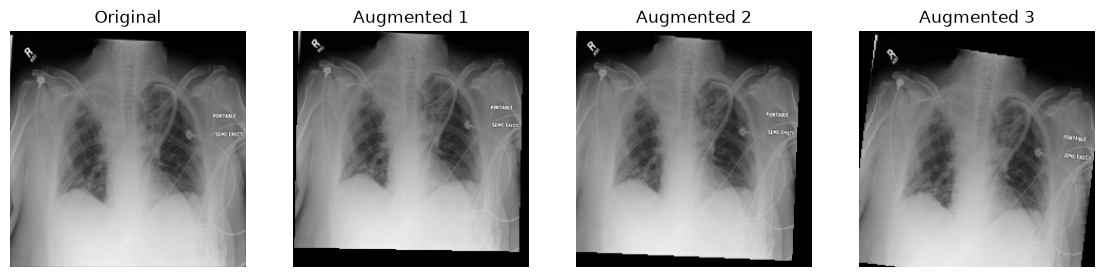

In [45]:
plain = CRDataset(train)
aug = CRDataset(train, train_tf)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(plain[0][0][0], cmap="gray")
axes[0].set_title("Original")
for k in range(1, 4):
    axes[k].imshow(aug[0][0][0], cmap="gray")
    axes[k].set_title(f"Augmented {k}")
for ax in axes:
    ax.axis("off")
plt.show()

In [48]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

for name, split in [("val", val), ("test", test)]:
    y_true = split["Target"]
    y_pred = [0] * len(split)
    print(name, "accuracy:", accuracy_score(y_true, y_pred),
          "sensitivity:", recall_score(y_true, y_pred))

val accuracy: 0.7518775274407856 sensitivity: 0.0
test accuracy: 0.7788896061975468 sensitivity: 0.0


In [49]:
confusion_matrix(y_true, y_pred)

array([[2413,    0],
       [ 685,    0]])

In [59]:
def extract_xray_features(image):
    pixels = image.flatten()

    mean = pixels.mean()
    std = pixels.std()
    p10, p50, p90 = np.percentile(pixels, [10, 50, 90])


    features = np.array([mean, std, p10, p50, p90], dtype=np.float32)
    return features

In [58]:
print(extract_xray_features(load_image(train["path"].iloc[0])))

[0.4236032  0.2170617  0.43529412 0.04313726 0.43529412 0.7254902 ]


In [61]:
X_train = np.array([
    extract_xray_features(load_image(path))
    for path in train["path"]
])

y_train = train["Target"].to_numpy()
X_test = np.array([
    extract_xray_features(load_image(path))
    for path in test["path"]
])
y_test = test["Target"].to_numpy()
X_val = np.array([
    extract_xray_features(load_image(path))
    for path in val["path"]
])
y_val = val["Target"].to_numpy()


In [62]:
np.save("data/X_train.npy", X_train)
np.save("data/X_val.npy", X_val)
np.save("data/X_test.npy", X_test)
np.save("data/y_train.npy", y_train)
np.save("data/y_val.npy", y_val)
np.save("data/y_test.npy", y_test)

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [74]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
).reshape(-1, 1)

In [75]:
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()

positive_weight = torch.tensor(
    positive_weight,
    dtype=torch.float32
)

In [81]:
import random


seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [82]:
model = nn.Linear(5, 1)

In [ ]:
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
for epoch in range(1000):

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = loss_function(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 1.2393909692764282
100 1.1519973278045654
200 1.1039928197860718
300 1.0793521404266357
400 1.0681357383728027
500 1.0634965896606445
600 1.0615675449371338
700 1.060590386390686
800 1.0598998069763184
900 1.0592845678329468


In [85]:
with torch.no_grad():
    val_logits = model(X_val_tensor)
    val_probabilities = torch.sigmoid(val_logits)

    val_predictions = (
        val_probabilities >= 0.5
    ).int()

In [86]:
from sklearn.metrics import precision_score
print("Validation accuracy:",
      accuracy_score(y_val, val_predictions))

print("Validation sensitivity/recall:",
      recall_score(y_val, val_predictions))

print("Validation precision:",
      precision_score(y_val, val_predictions))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_predictions))

Validation accuracy: 0.6629116117850953
Validation sensitivity/recall: 0.6379511059371362
Validation precision: 0.3903133903133903
Validation confusion matrix:
[[1747  856]
 [ 311  548]]


In [87]:
loss_function = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
for epoch in range(10000):

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = loss_function(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
        print(epoch, loss.item())

0 1.0586872100830078
100 1.0553439855575562
200 1.0525586605072021
300 1.05024254322052
400 1.048324704170227
500 1.0467402935028076
600 1.0454293489456177
700 1.0443378686904907
800 1.043418526649475
900 1.042630672454834
1000 1.0419410467147827
1100 1.0413235425949097
1200 1.0407588481903076
1300 1.0402331352233887
1400 1.039737582206726
1500 1.039266586303711
1600 1.0388169288635254
1700 1.038387417793274
1800 1.037976622581482
1900 1.037584900856018
2000 1.0372116565704346
2100 1.0368571281433105
2200 1.0365208387374878
2300 1.0362027883529663
2400 1.0359026193618774
2500 1.035620093345642
2600 1.0353546142578125
2700 1.0351060628890991
2800 1.034873604774475
2900 1.0346568822860718
3000 1.034455418586731
3100 1.0342684984207153
3200 1.0340958833694458
3300 1.033936619758606
3400 1.0337902307510376
3500 1.033656120300293
3600 1.0335339307785034
3700 1.0334227085113525
3800 1.0333219766616821
3900 1.0332311391830444
4000 1.0331496000289917
4100 1.0330767631530762
4200 1.033012032508

In [88]:
print("Validation accuracy:",
      accuracy_score(y_val, val_predictions))

print("Validation sensitivity/recall:",
      recall_score(y_val, val_predictions))

print("Validation precision:",
      precision_score(y_val, val_predictions))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_predictions))

Validation accuracy: 0.6629116117850953
Validation sensitivity/recall: 0.6379511059371362
Validation precision: 0.3903133903133903
Validation confusion matrix:
[[1747  856]
 [ 311  548]]


In [89]:
from sklearn.metrics import roc_auc_score

val_auc = roc_auc_score(
    y_val,
    val_probabilities.detach().numpy().ravel()
)

print("Weighted validation AUC:", val_auc)

Weighted validation AUC: 0.672404948709222


In [90]:
from sklearn.metrics import recall_score, confusion_matrix, roc_auc_score

unweighted_model = nn.Linear(5, 1)
unweighted_loss = nn.BCEWithLogitsLoss()
unweighted_optimizer = torch.optim.Adam(
    unweighted_model.parameters(),
    lr=0.001
)

for epoch in range(1000):
    unweighted_optimizer.zero_grad()
    logits = unweighted_model(X_train_tensor)
    loss = unweighted_loss(logits, y_train_tensor)
    loss.backward()
    unweighted_optimizer.step()

with torch.no_grad():
    p_weighted = torch.sigmoid(model(X_val_tensor)).numpy().ravel()
    p_unweighted = torch.sigmoid(
        unweighted_model(X_val_tensor)
    ).numpy().ravel()

for name, p in [
    ("weighted", p_weighted),
    ("unweighted", p_unweighted)
]:
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_val, pred
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_val, p)

    print(
        name,
        "sensitivity:", sensitivity,
        "specificity:", specificity,
        "AUC:", auc
    )

weighted sensitivity: 0.6903376018626309 specificity: 0.6219746446407991 AUC: 0.6831720540953685
unweighted sensitivity: 0.0 specificity: 1.0 AUC: 0.6640184581505088


In [91]:
final_model = model
final_name = "weighted"

print("Final model:", final_name)

Final model: weighted


In [93]:

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)
with torch.no_grad():
    test_probabilities = torch.sigmoid(
        final_model(X_test_tensor)
    ).numpy().ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

print("Final model:", final_name)
print("Sensitivity:", tp / (tp + fn))
print("Specificity:", tn / (tn + fp))
print("AUC:", roc_auc_score(y_test, test_probabilities))

Final model: weighted
Sensitivity: 0.6175182481751825
Specificity: 0.6319933692498964
AUC: 0.6526727186377923


In [95]:
from sklearn.metrics import f1_score
for name, p in [
    ("weighted", p_weighted),
    ("unweighted", p_unweighted)
]:
    pred = (p >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, pred
    ).ravel()

    print("\n", name)
    print("Sensitivity:", tp / (tp + fn))
    print("Specificity:", tn / (tn + fp))
    print("Precision:", precision_score(y_val, pred))
    print("Accuracy:", accuracy_score(y_val, pred))
    print("F1:", f1_score(y_val, pred))
    print("AUC:", roc_auc_score(y_val, p))
    print("Confusion matrix:")
    print(confusion_matrix(y_val, pred))


 weighted
Sensitivity: 0.6903376018626309
Specificity: 0.6219746446407991
Precision: 0.3760304375396322
Accuracy: 0.6389370306181398
F1: 0.48686371100164205
AUC: 0.6831720540953685
Confusion matrix:
[[1619  984]
 [ 266  593]]

 unweighted
Sensitivity: 0.0
Specificity: 1.0
Precision: 0.0
Accuracy: 0.7518775274407856
F1: 0.0
AUC: 0.6640184581505088
Confusion matrix:
[[2603    0]
 [ 859    0]]


/opt/anaconda3/envs/lab1mobile/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [96]:
test_predictions = (
    test_probabilities >= 0.5
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions
).ravel()

print("Final model:", final_name)
print("Sensitivity:", tp / (tp + fn))
print("Specificity:", tn / (tn + fp))
print("Precision:", precision_score(y_test, test_predictions))
print("Accuracy:", accuracy_score(y_test, test_predictions))
print("F1:", f1_score(y_test, test_predictions))
print("AUC:", roc_auc_score(y_test, test_probabilities))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_predictions))

Final model: weighted
Sensitivity: 0.6175182481751825
Specificity: 0.6319933692498964
Precision: 0.32265446224256294
Accuracy: 0.6287927695287282
F1: 0.42384769539078154
AUC: 0.6526727186377923
Confusion matrix:
[[1525  888]
 [ 262  423]]


In [97]:
images_train = np.zeros(
    (len(train), 224, 224),
    dtype=np.uint8
)

for i, path in enumerate(train["path"]):
    image = pydicom.dcmread(path).pixel_array
    image = Image.fromarray(image).resize((224, 224))
    images_train[i] = np.array(image, dtype=np.uint8)

np.save("data/images_train.npy", images_train)

In [98]:
images_val = np.zeros(
    (len(val), 224, 224),
    dtype=np.uint8
)

for i, path in enumerate(val["path"]):
    image = pydicom.dcmread(path).pixel_array
    image = Image.fromarray(image).resize((224, 224))
    images_val[i] = np.array(image, dtype=np.uint8)

np.save("data/images_val.npy", images_val)

In [99]:
images_test = np.zeros(
    (len(test), 224, 224),
    dtype=np.uint8
)

for i, path in enumerate(test["path"]):
    image = pydicom.dcmread(path).pixel_array
    image = Image.fromarray(image).resize((224, 224))
    images_test[i] = np.array(image, dtype=np.uint8)

np.save("data/images_test.npy", images_test)

In [100]:
class CachedDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        x = torch.from_numpy(self.images[i])
        x = x.float() / 255
        x = x.unsqueeze(0)

        if self.transform:
            x = self.transform(x)

        y = torch.tensor(
            self.labels[i],
            dtype=torch.float32
        )

        return x, y

In [101]:
ds = CachedDataset(
    images_train,
    y_train,
    train_tf
)

x, y = ds[0]

print(len(ds))
print(x.shape)
print(x.dtype)
print(y)

19124
torch.Size([1, 224, 224])
torch.float32
tensor(0.)


In [102]:
from torch.utils.data import DataLoader

train_dataset = CachedDataset(
    images_train,
    y_train,
    train_tf
)

val_dataset = CachedDataset(
    images_val,
    y_val
)

test_dataset = CachedDataset(
    images_test,
    y_test
)

In [103]:
generator = torch.Generator()
generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [104]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

print(model.conv1)
print(model.fc)

print("conv1 input channels:", model.conv1.in_channels)
print("fc input size:", model.fc.in_features)
print("fc output size:", model.fc.out_features)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/mohamed.farrag/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


KeyboardInterrupt: 